In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df.shape

(100, 4)

In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [8]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [13]:
import matplotlib.pyplot as plt

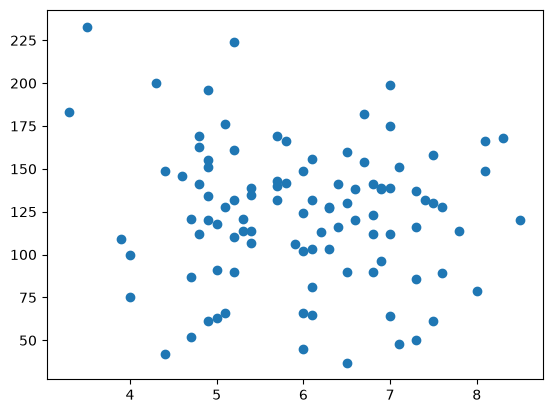

In [10]:
plt.scatter(df['cgpa'],df['iq'])

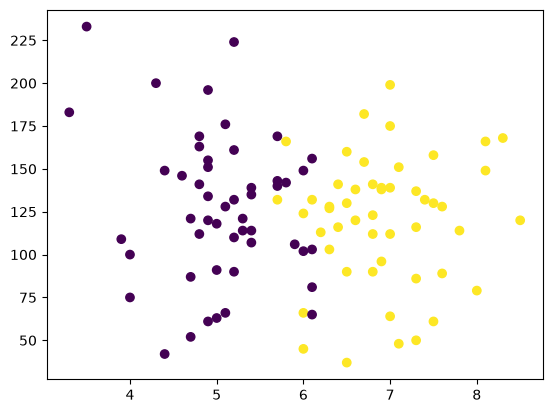

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [14]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [15]:
X

,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [16]:
y.shape

(100,)

In [17]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [18]:
X_train

,Unnamed: 0,cgpa
35,35,6.8
50,50,3.5
12,12,5.4
43,43,6.8
81,81,5.4
...,...,...
72,72,7.3
48,48,6.6
98,98,6.3
82,82,6.5


In [19]:
X_test

,Unnamed: 0,cgpa
90,90,7.3
18,18,4.0
2,2,5.3
79,79,6.5
38,38,6.5
41,41,5.4
3,3,7.4
28,28,5.2
87,87,5.7
47,47,5.2


In [20]:
y_train

35    1
50    0
12    0
43    1
81    0
     ..
72    1
48    1
98    1
82    1
30    1
Name: placement, Length: 90, dtype: int64

In [21]:
y_test

90    1
18    0
2     0
79    1
38    1
41    0
3     1
28    0
87    1
47    0
Name: placement, dtype: int64

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
X_train = scaler.fit_transform(X_train)

In [25]:
X_train

array([[-0.53229113,  0.68959151],
       [-0.00661957, -2.17887738],
       [-1.33832086, -0.52733468],
       [-0.25193296,  0.68959151],
       [ 1.07976833, -0.52733468],
       [ 0.8694997 , -1.04887448],
       [-0.21688819,  1.29805461],
       [-0.5673359 , -1.04887448],
       [ 1.32508172, -1.39656768],
       [ 0.0284252 , -1.04887448],
       [ 0.58914154, -0.87502788],
       [ 0.93958924,  1.12420801],
       [-0.04166434, -0.52733468],
       [ 1.57039512, -1.48349098],
       [ 0.48400722,  0.86343811],
       [-1.02291792,  0.95036141],
       [ 0.2737386 ,  1.73267111],
       [ 1.36012649, -0.96195118],
       [ 1.60543989, -1.39656768],
       [-1.54858948, -0.26656479],
       [ 1.21994741, -0.17964149],
       [-1.51354471, -0.87502788],
       [-0.46220159,  1.81959441],
       [-0.18184342, -0.00579489],
       [ 0.55409676,  0.77651481],
       [-1.4084104 , -0.00579489],
       [ 0.51905199,  1.81959441],
       [ 0.97463401,  0.08112841],
       [ 0.65923108,

In [26]:
X_test = scaler.transform(X_test)

In [27]:
X_test

array([[ 1.39517126,  1.12420801],
       [-1.12805223, -1.74426088],
       [-1.68876856, -0.61425798],
       [ 1.00967878,  0.42882161],
       [-0.42715682,  0.42882161],
       [-0.3220225 , -0.52733468],
       [-1.65372379,  1.21113131],
       [-0.77760452, -0.70118128],
       [ 1.29003695, -0.26656479],
       [-0.11175388, -0.70118128]])

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
clf = LogisticRegression()

In [30]:
# Model Training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [31]:
y_pred = clf.predict(X_test)

In [32]:
y_test

90    1
18    0
2     0
79    1
38    1
41    0
3     1
28    0
87    1
47    0
Name: placement, dtype: int64

In [33]:
from sklearn.metrics import accuracy_score

In [34]:
accuracy_score(y_test,y_pred)

0.9

In [56]:
from mlxtend.plotting import plot_decision_regions

ModuleNotFoundError: No module named 'mlxtend'

In [57]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.4 MB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 1.4 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.3 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.1 MB/s  0:00:01
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.3 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.3 MB 1.4 MB/s eta 0:00:06
   ----- --------------------------------

In [37]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

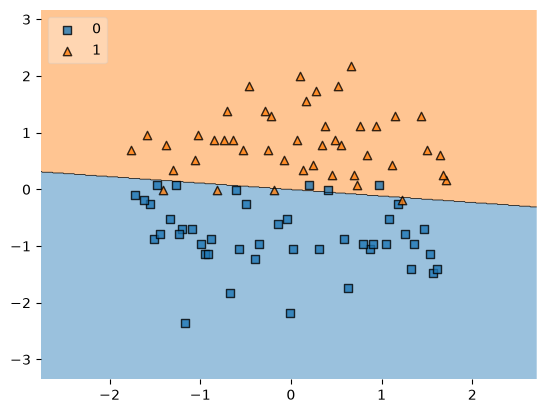

In [39]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [40]:
import pickle

In [41]:
pickle.dump(clf,open('model.pkl','wb'))